# USA Real Estate Data Quality Audit — Part 3: Do duplicate listings inflate a price model's score?

**Author:** Mariam Fathi · **Code:** `src/reaudit/leakage.py`, `experiments/run_leakage.py`, `experiments/run_naive_split.py`

[Part 1](01_root_cause_analysis.ipynb) found that many properties appear more than once (a `for_sale` and a `sold`
record of the same house, or relistings). The standard worry: with a random train/test split, a model can see one
record of a house in training and be tested on another record of the same house, so its test score overstates how
well it values houses it has never seen. This notebook measures that effect instead of assuming it.

## Summary

- 14% of records share their property with another record. With a random 80/20 split, 11.6% of test rows have a
  "twin" of the same property in training.
- **The aggregate inflation is real but small.** Random forest: R² +0.0033 (95% CI ±0.0008), median error −0.36
  points. Gradient boosting: +0.0015 ± 0.0026, not distinguishable from zero over 5 seeds. Ridge: none.
- **The mechanism is memorisation, confined to the twinned rows.** On test rows whose property is in training, random
  forest's R² rises by **+0.041** and its error falls 14%; on all other rows nothing improves. The effect grows
  steadily with the share of twins kept (dose-response, p < 0.001).
- It stays small because only 12% of test rows have a twin, and although most twins share the price, almost none
  share the features (status and sale year differ), so the model can't simply look the answer up (§4).
- Whether this counts as leakage depends on the use case (§6).

## Design

The usual check compares a random split with a property-grouped split. Those two splits have **different test sets**,
so their difference mixes leakage with ordinary sampling noise (§5 shows how much). This experiment holds the test set
fixed instead:

1. Split records 80/20 at random (5 seeds). A training record is a **twin** if its property also appears in the test set.
2. Train each model on a training set that keeps a share *f* of the twins, *f* ∈ {0, 0.25, 0.5, 0.75, 1}. To keep
   training size identical, every condition drops the same number of rows: the removed twins plus random non-twins.
3. Score every condition on the **same test rows**. The difference between *f* = 1 (an ordinary random split) and
   *f* = 0 (no twins) is the inflation caused by duplicates, paired within each seed.

| | |
|---|---|
| Property identity | encoded street + zip code + city + state (records missing any of these are their own property) |
| Target | log price; listings priced $10,000–$50M |
| Features | bed, bath, lot acres, house size, zip code, state, status, year of previous sale |
| Models | Ridge (linear), gradient boosting (sklearn `HistGradientBoostingRegressor`), random forest (60 trees) |
| Metrics | R² on log price; median absolute percentage error (MdAPE) on price |

## 1. Setup

In [1]:
# Runs from notebooks/ in the repo, or on Kaggle: there it clones the repo (turn Internet on in the settings)
import os
import subprocess
import sys

REPO = 'https://github.com/Mariam-Fathi/real-estate-audit'
if os.path.exists('/kaggle/input') and not os.path.exists('../src/reaudit'):
    subprocess.run(['git', 'clone', '--depth', '1', REPO, '/kaggle/working/real-estate-audit'], check=True)
    os.chdir('/kaggle/working/real-estate-audit/notebooks')
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

from reaudit import leakage
from reaudit.data import load_raw

m = pd.read_csv('../results/leakage_metrics.csv')
naive = pd.read_csv('../results/leakage_naive.csv')
mech = pd.read_csv('../results/leakage_mechanism.csv')
SEEDS = m.seed.nunique()
MODELS = ['ridge', 'gradient boosting', 'random forest']

BLUE, ORANGE, GRAY = '#2a78d6', '#eb6834', '#b4b2ab'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#c9c8c3', 'axes.grid': True, 'grid.color': '#ecebe7', 'grid.linewidth': 0.8,
    'axes.axisbelow': True, 'axes.titlesize': 13, 'axes.titleweight': 'bold', 'axes.titlelocation': 'left',
    'axes.labelcolor': '#52514e', 'xtick.color': '#52514e', 'ytick.color': '#52514e', 'font.size': 10.5,
})


def ci(x):
    x = np.asarray(x, dtype=float)
    return x.mean(), stats.t.ppf(0.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x))

In [2]:
df = leakage.prepare(load_raw())
size = df.groupby('pid')['pid'].transform('size')
tr, te, twin = leakage.split_with_twins(df, seed=0)
seen = np.isin(df.pid.to_numpy()[te], df.pid.to_numpy()[tr])
print(f'{len(df):,} records of {df.pid.nunique():,} properties; '
      f'{(size > 1).mean():.1%} of records share their property with another record')
print(f'seed 0: {twin.sum():,} twins in training ({twin.mean():.1%}), {seen.mean():.1%} of test rows have a twin')

2,205,440 records of 2,038,692 properties; 14.0% of records share their property with another record
seed 0: 65,002 twins in training (3.7%), 11.6% of test rows have a twin


## 2. How much does a random split inflate the score?

In [3]:
full = m[m.subset == 'all test rows']
wide = full[full.keep_share.isin([0.0, 1.0])].pivot_table(index=['model', 'seed'], columns='keep_share',
                                                          values=['r2', 'median_ape'])
rows = []
for model in MODELS:
    w = wide.loc[model]
    d_r2 = w[('r2', 1.0)] - w[('r2', 0.0)]
    d_ape = w[('median_ape', 1.0)] - w[('median_ape', 0.0)]
    rows.append({'model': model,
                 'R² without twins': w[('r2', 0.0)].mean(), 'R² with twins': w[('r2', 1.0)].mean(),
                 'R² inflation': ci(d_r2)[0], '± (95% CI)': ci(d_r2)[1],
                 'p (paired t)': stats.ttest_rel(w[('r2', 1.0)], w[('r2', 0.0)]).pvalue,
                 'MdAPE without': w[('median_ape', 0.0)].mean(), 'MdAPE change': ci(d_ape)[0]})
infl = pd.DataFrame(rows).set_index('model')
infl.style.format({'R² without twins': '{:.4f}', 'R² with twins': '{:.4f}', 'R² inflation': '{:+.4f}',
                   '± (95% CI)': '{:.4f}', 'p (paired t)': '{:.3f}', 'MdAPE without': '{:.1%}',
                   'MdAPE change': '{:+.2%}'})

,R² without twins,R² with twins,R² inflation,± (95% CI),p (paired t),MdAPE without,MdAPE change
model,,,,,,,
ridge,0.5610,0.5610,+0.0000,0.0000,0.001,34.4%,-0.03%
gradient boosting,0.7236,0.7250,+0.0015,0.0026,0.200,25.5%,-0.19%
random forest,0.7924,0.7957,+0.0033,0.0008,0.000,18.4%,-0.36%


In [4]:
rf_low, rf_high = infl.loc['random forest', 'R² inflation'] - infl.loc['random forest', '± (95% CI)'], \
                  infl.loc['random forest', 'R² inflation'] + infl.loc['random forest', '± (95% CI)']
assert rf_low > 0                                          # random forest: a real, positive effect
assert abs(infl.loc['ridge', 'R² inflation']) < 0.0005     # ridge: none
assert infl['R² inflation'].abs().max() < 0.01             # and everywhere small

- **Random forest** gains R² +0.0033 from twins, a small but clear effect (the interval excludes zero in every
  seed). Its median price error falls by about a third of a percentage point.
- **Gradient boosting** gains +0.0015 on average, but individual seeds range from −0.0008 to +0.0040, so 5 seeds
  can't separate it from zero. (Its early stopping is turned off so that a random validation split doesn't add noise;
  the remaining spread comes from how much its trees change when ~65,000 training rows are swapped.)
- **Ridge** cannot memorise individual houses, and twins make no practical difference.

The ranking matches capacity: the model best able to fit individual records gains the most.

### Dose-response (random forest)

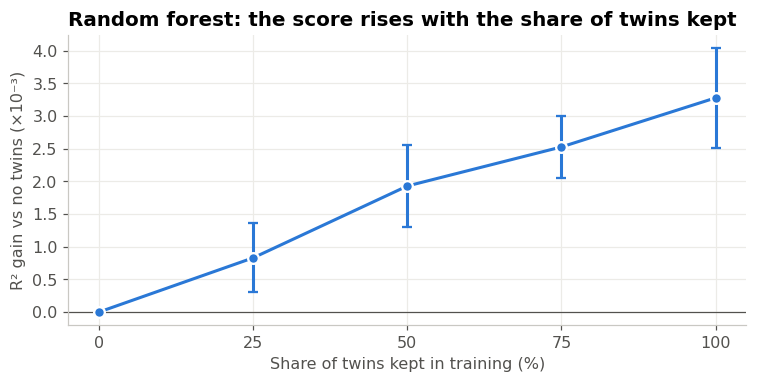

slope: 3.30 ×10⁻³ R² per 100% of twins (p = 1.5e-12)


In [5]:
rf = full[full.model == 'random forest'].copy()
base = rf[rf.keep_share == 0].set_index('seed')['r2']
rf['gain'] = rf.r2 - rf.seed.map(base)
dose = rf.groupby('keep_share')['gain'].apply(lambda g: pd.Series(ci(g), index=['mean', 'h'])).unstack()
slope = stats.linregress(rf.keep_share, rf.gain)
assert slope.slope > 0 and slope.pvalue < 0.01

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.errorbar(dose.index * 100, dose['mean'] * 1000, yerr=dose['h'] * 1000, color=BLUE, marker='o', ms=7, lw=2,
            capsize=3, mec='white', mew=1.5)
ax.axhline(0, color='#52514e', lw=0.8)
ax.set_xlabel('Share of twins kept in training (%)')
ax.set_ylabel('R² gain vs no twins (×10⁻³)')
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_title('Random forest: the score rises with the share of twins kept')
plt.tight_layout(); plt.show()
print(f'slope: {slope.slope * 1000:.2f} ×10⁻³ R² per 100% of twins (p = {slope.pvalue:.1e})')

## 3. The mechanism: twins help exactly the test rows they duplicate

If twins inflate the score through memorisation, the gain should appear **only** on test rows whose property has a
twin in training, and not on the other 88%. Seed 0 gives a per-record paired comparison: the same test row, predicted
by a model trained with and without the twins.

In [6]:
# per-record errors of seed 0 summarised by leakage.mechanism_table (results/leakage_mechanism.csv)
assert (mech[(mech.model == 'random forest') & (mech.seen == 'twin in training')].change < -0.02).all()
mech.round(4)

,model,seen,n,err_without,err_with,change
0,gradient boosting,no twin,389846,0.3962,0.3970,0.0008
1,gradient boosting,twin in training,51107,0.3461,0.3406,-0.0055
2,random forest,no twin,389846,0.3184,0.3191,0.0007
3,random forest,twin in training,51107,0.2861,0.2462,-0.0399
4,ridge,no twin,389846,0.5189,0.5187,-0.0002
5,ridge,twin in training,51107,0.4561,0.4554,-0.0007


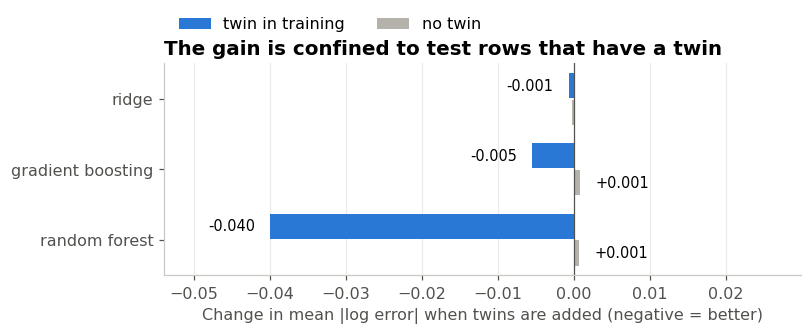

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 3.2))
y = np.arange(len(MODELS))
for j, (grp, color) in enumerate([('twin in training', BLUE), ('no twin', GRAY)]):
    vals = [mech[(mech.model == mdl) & (mech.seen == grp)].change.iloc[0] for mdl in MODELS]
    bars = ax.barh(y + (j - 0.5) * 0.38, vals, height=0.36, color=color, label=grp)
    for b, v in zip(bars, vals):
        ax.text(v - 0.002 if v < 0 else v + 0.002, b.get_y() + b.get_height() / 2, f'{v:+.3f}',
                va='center', ha='right' if v < 0 else 'left', fontsize=9.5) if abs(v) >= 0.0005 else None
ax.axvline(0, color='#52514e', lw=0.8)
ax.set_yticks(y, MODELS); ax.invert_yaxis()
ax.set_xlabel('Change in mean |log error| when twins are added (negative = better)')
ax.set_title('The gain is confined to test rows that have a twin')
ax.legend(frameon=False, loc='lower left', bbox_to_anchor=(0.0, 1.08), ncol=2)
ax.grid(axis='y', visible=False)
xmin = mech.change.min()
ax.set_xlim(xmin * 1.35, abs(xmin) * 0.75)
plt.tight_layout(); plt.show()

For random forest, test rows with a twin get **14% lower error** (mean |log error| 0.286 → 0.246) when the twins are
in training; their R² rises from 0.798 to 0.839. The other 88% of test rows get *slightly worse* (+0.0007): in
the condition with twins, those twin rows take the place of records of other properties, so the model learns about
fewer distinct houses. This is the signature of memorisation, not of more data. Gradient boosting shows the same
pattern at a tenth of the size.

## 4. Why the aggregate effect is small

Two things limit it: few test rows have a twin, and a twin is rarely an exact copy of the test row.

In [8]:
PHYSICAL = ['bed', 'bath', 'house_size', 'acre_lot']
T = df.iloc[te][seen].reset_index(names='row')
R = df.iloc[tr][twin]
pairs = T[['row', 'pid', 'price'] + leakage.FEATURES].merge(
    R[['pid', 'price'] + leakage.FEATURES], on='pid', suffixes=('', '_twin'))


def same(cols, missing_matches):
    ok = np.ones(len(pairs), bool)
    for c in cols:
        a, b = pairs[c], pairs[c + '_twin']
        ok &= ((a == b) | (a.isna() & b.isna()) | ((a.isna() | b.isna()) & missing_matches)).to_numpy()
    return ok


pairs['same_home'] = same(PHYSICAL, missing_matches=True)
pairs['same_price'] = (pairs.price == pairs.price_twin).to_numpy()
pairs['same_features'] = same(leakage.FEATURES, missing_matches=False)
per_row = pairs.groupby('row')[['same_home', 'same_price', 'same_features']].any()
n_twins = pairs.groupby('row').size()
print(f'test rows with a twin in training          : {seen.mean():.1%}')
print(f'  ...with exactly one twin                 : {(n_twins == 1).mean():.1%}')
print(f'  ...whose twin is physically the same home: {per_row.same_home.mean():.1%}')
print(f'  ...whose twin has the identical price    : {per_row.same_price.mean():.1%}')
print(f'  ...whose twin has identical features     : {per_row.same_features.mean():.1%}')
assert per_row.same_features.mean() < 0.1 < 0.7 < per_row.same_price.mean()

test rows with a twin in training          : 11.6%
  ...with exactly one twin                 : 86.4%
  ...whose twin is physically the same home: 82.9%
  ...whose twin has the identical price    : 80.2%
  ...whose twin has identical features     : 4.3%


Most twins carry the **same price** as the test row (Part 1's `for_sale` + `sold` pairs), but almost none have the
same **features**: the status differs, and so does the previous-sale year (the `for_sale` record holds the older sale,
the `sold` record the 2021–22 one). The model therefore can't look the answer up; it can only place the test row
next to a training point with the right price, which narrows the error without removing it. The 17% of twins that are
not the same home are other units or floor plans at the same encoded address, such as new-build developments with
dozens of `ready_to_build` listings at one address (the ambiguity Part 2 found).

## 5. Cross-check: the usual random vs grouped comparison

The common way to check for leakage is to train once with a random split and once with a property-grouped split, then
compare the scores. The two runs have different test sets, so the difference also includes other differences between
the splits. Here are both designs for the same 5 seeds.

In [9]:
nv = naive.pivot_table(index=['model', 'seed'], columns='split', values='r2')
nv['diff'] = nv['random'] - nv['grouped']
paired = wide[('r2', 1.0)] - wide[('r2', 0.0)]
comp = pd.DataFrame({
    'naive: mean': nv.groupby('model')['diff'].mean(), 'naive: SD across seeds': nv.groupby('model')['diff'].std(),
    'paired: mean': paired.groupby('model').mean(), 'paired: SD across seeds': paired.groupby('model').std(),
}).loc[['gradient boosting', 'random forest']]
comp['SD ratio'] = comp['naive: SD across seeds'] / comp['paired: SD across seeds']
comp.round(4)

,naive: mean,naive: SD across seeds,paired: mean,paired: SD across seeds,SD ratio
model,,,,,
gradient boosting,0.0010,0.0009,0.0015,0.0021,0.4214
random forest,0.0041,0.0012,0.0033,0.0006,1.9497


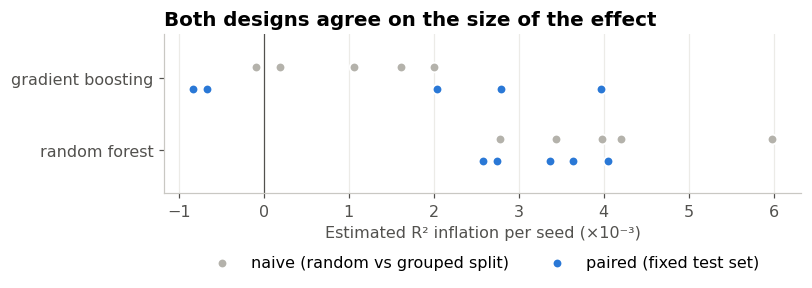

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 3.0))
for i, mdl in enumerate(['gradient boosting', 'random forest']):
    nvals = nv.loc[mdl, 'diff'].to_numpy() * 1000
    pvals = paired.loc[mdl].to_numpy() * 1000
    ax.scatter(nvals, np.full_like(nvals, i - 0.15), color=GRAY, s=40, edgecolor='white', lw=1.2, zorder=3,
               label='naive (random vs grouped split)' if i == 0 else None)
    ax.scatter(pvals, np.full_like(pvals, i + 0.15), color=BLUE, s=40, edgecolor='white', lw=1.2, zorder=3,
               label='paired (fixed test set)' if i == 0 else None)
ax.axvline(0, color='#52514e', lw=0.8)
ax.set_yticks([0, 1], ['gradient boosting', 'random forest']); ax.set_ylim(-0.6, 1.6); ax.invert_yaxis()
ax.set_xlabel('Estimated R² inflation per seed (×10⁻³)')
ax.set_title('Both designs agree on the size of the effect')
ax.legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2)
ax.grid(axis='y', visible=False)
plt.tight_layout(); plt.show()

Both designs agree: about +0.004 for random forest and about +0.001 for gradient boosting. On a dataset this
large, the test sets are big enough (about 440,000 rows) that the usual check isn't misleadingly noisy. What the
paired design adds is **attribution**: the per-record comparison (§3) shows *which* rows gain and why, and the
dose-response (§2) shows the score tracks the share of twins. The usual check can show a gap but can't show that
duplicates caused it.

## 6. Is it leakage at all? It depends on the use case

Whether a twin in training is leakage depends on what the model will be used for:

- **Valuing homes that have never been listed before** (an automated valuation for new inventory): the leak-free
  estimate is the right one, and a random split overstates accuracy, slightly here.
- **Re-pricing listings that are already in the database** (a relisting, or estimating the sale price of a home
  currently for sale): the model *will* have seen earlier records of the same home in production, so the random-split
  estimate is closer to deployment conditions.

The split should mirror the deployment question. That is a design decision to state, not a default to inherit.

## 7. Limitations

1. **Property identity relies on the dataset's encoded street id**, which has no unit number. 17% of twins are other
   units or floor plans at the same address rather than the same home, so "property" here means "address". Records
   with a missing street (0.5%) can't be matched at all.
2. **The models are not tuned.** A model with more capacity to memorise (deeper forests, nearest neighbours, or a
   property identifier among the features) would gain more; these results describe typical baselines, not the worst case.
3. **No time ordering.** Relistings happen over time; a time-based split (train on earlier listings, test on later
   ones) is the realistic setting for a valuation model and would be a natural extension.
4. **One snapshot of one dataset**, where only 14% of records share a property. Data with more repeated snapshots
   would carry more leakage, as the dose-response suggests.

## 8. Takeaways

- Duplicate properties do inflate a random-split score, but on this dataset the effect is **small**: about 0.003 R²
  for a random forest and not detectable for gradient boosting. That is a useful, honest result. The duplicates
  found in Part 1 are worth removing for cleanliness, but they don't invalidate a model evaluated with a random split.
- The effect is **concentrated**: for the 12% of test listings whose property was seen in training, the forest's
  error is 14% lower than it would be for an unseen house. A valuation service reporting one accuracy number would
  overstate its accuracy on new properties for exactly those cases.
- Leakage depends on **model capacity** (forest > boosting > linear) and on the **share of duplicates** (dose-response).
  Datasets with more repeated snapshots would show larger inflation.
- A paired design (fixed test set, size-matched training sets) can **attribute** the gap to duplicates, which a plain
  random-vs-grouped comparison can't.